# Long logic sentences and FOL error suite — source re-verification demo

This notebook walks through `data.py` of the artifact **art_zcwCQgTqk6DN**, the script that turns the pipeline's
assembled groups into the final `full_data_out.json`. It **re-verifies every row against its sources** and
stores the result as `metadata_source_verified`, `metadata_source_file` and `metadata_verify_notes`. Rows are never dropped.

The dataset holds two held-out NL→FOL faithfulness tables used to meta-evaluate gold-free FOL-quality metrics:

* **PERTURB** (`perturb_suite`): typed mutants of trusted reference formulas. Operators: NEG, REV, QUANT, RESTR,
  CONN, MOVE, DROP, ADD, SWAP, BIND and MEANING_RENAME, placed at DOWN/UP monotonicity positions. Each mutant is labelled
  `ERROR`. The suite also has meaning-preserving controls (RENAME, REORDER, CONTRAPOSITIVE/DEMORGAN), each labelled
  `CORRECT`. Bases are dataset-E references (TRUSTED_AGREED / GOLD_PANEL_OK / PANEL_REPAIRED) and R_COMP weak readings.
* **R_COMP** (`rcomp_sentences`): long templated sentences (≥25 words, ≥3 conditions, one unless/except/provided-that/
  only-if clause). Their weak and strong reference readings come from the template, built from an atom lexicon mined
  from verified FOLIO/MALLS references.

The checks it runs:

| group | check |
|---|---|
| `rcomp_sentences` | every lexicon entry traces to a FOLIO-v2-train premise with a matching folio-refined formula, or to a dataset-E row (plus MALLS for GOLD_PANEL_OK); the composed text is not in the screen-exclusion hash set |
| `perturb_suite` | base text and formula equal the dataset-E row / MALLS / FOLIO source; R_COMP bases equal the weak reading; `item_id` recomputed from its recipe |
| `adjudicator_check` | the item exists in `perturb_suite` with the same candidate and the same known label |

**Demo data.** `mini_demo_data.json` is a curated slice with 10 R_COMP sentences (one per template), 78 PERTURB rows
(every operator/control × base source, plus some matched DOWN/UP pairs) and 8 adjudicator QA rows. It also holds
*exactly the source records* needed to verify those rows: FOLIO v2, folio-refined, MALLS-v0.1, dataset-E rows and
the screen-exclusion texts. The notebook therefore needs no large downloads. The full artifact has 350 R_COMP
sentences, 5,102 PERTURB rows and 60 adjudicator rows.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# matplotlib, pandas — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import csv
import hashlib
import json
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path

from loguru import logger

# additional imports for the notebook's summary / visualization cell
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_StxQVNnY7aQW/round-2/dataset-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print("demo rows:", data["metadata"]["rows"])

Curated demo slice of art_zcwCQgTqk6DN (R_COMP + PERTURB NL->FOL faithfulness tables). 'assembled' mirrors work/assembled.json (the input of data.py) restricted to the demo rows; 'lexicon' holds the atom-lexicon entries those R_COMP rows use; 'sources' holds exactly the FOLIO-v2 / folio-refined / MALLS-v0.1 / dataset-E records needed to re-verify them, plus the full text fields of the screen-exclusion sources.
demo rows: {'rcomp_sentences': 10, 'perturb_suite': 78, 'adjudicator_check': 8}


## Config

There is no training loop. The only tunable is how many rows of each group are verified. The values below are
prefix slices of the demo groups, and the demo data is ordered so that prefixes stay self-consistent. Row checks
depend on each other: a PERTURB row with an R_COMP base needs its sentence in the `rcomp_sentences` slice, and an
adjudicator row needs its item in the `perturb_suite` slice. Very small slices can therefore show "mismatch" /
"not found" notes caused only by the slicing. `None` means all demo rows. The original script processes every row:
350 / 5,102 / 60.

In [5]:
N_RCOMP = None       # rcomp_sentences rows to verify (demo max 10; original: all 350)
N_PERTURB = None     # perturb_suite rows to verify (demo max 78; original: all 5,102)
N_ADJ = None         # adjudicator_check rows to verify (demo max 8; original: all 60)

## Setup: paths and logging

In the original script `ROOT` is the artifact workspace and `T` its `temp/datasets/` source folder. In the notebook,
the sources come from `data["sources"]`, so `T` is unused. `ROOT` is the current directory, where outputs and the log file go.

In [6]:
ROOT = Path.cwd()                      # original: Path(__file__).resolve().parent
T = ROOT / "temp" / "datasets"         # original source folder (not used: sources are in data["sources"])
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")

2

## Text / formula normalisation helpers

These are exact copies of dataset E's `select_sentences.py` helpers:

* `norm` lowercases text, unifies quotes and strips punctuation.
* `h` hashes normalised text; it is used for the screen-exclusion set.
* `split_sents` splits a passage into sentences.
* `fsq` removes all whitespace from a formula, so formulas compare as strings.

In [7]:
# ---- exact copies of dataset E's src_e/select_sentences.py helpers (kept standalone so data.py needs no z3)
def norm(s: str) -> str:
    s = s.lower().replace("’", "'").replace("‘", "'").replace("“", '"').replace("”", '"')
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    return re.sub(r"\s+", " ", s).strip()


def h(s: str) -> str:
    return hashlib.sha1(norm(s).encode()).hexdigest()


def split_sents(block: str) -> list[str]:
    return [p.strip() for p in re.split(r"(?<=[.!?])\s+|\n+", block) if p.strip()]


def jl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()]


def fsq(f: str) -> str:
    """Formula comparison key: whitespace removed."""
    return re.sub(r"\s+", "", f or "")

## Loading the sources

`load_sources` builds the lookup tables that every check uses:

* `folio_train_premises`: the normalised FOLIO-v2 train premises.
* `refined`: maps each premise to its folio-refined formula(s), for stories whose NL and FOL premise lists align.
* `malls_train`: maps each MALLS-v0.1 train NL sentence to its FOL formula(s).
* `exclusion`: sha1 hashes of every sentence in the held-out / evaluation sources (FOLIO v2 validation, folio-refined
  validation, the DSAVlab curated sets, MALLS test and Logic-LM FOLIO-dev prompts). A composed R_COMP sentence must not
  collide with any of them.
* `E_by_sid` / `E_by_text`: dataset E's held-out rows, with their trust status (TRUSTED_AGREED, GOLD_PANEL_OK,
  PANEL_REPAIRED, …).

**Only change from the original:** each `jl(T / file)`, `csv.DictReader(open(T / file))` or `json.loads((T / file).read_text())`
now reads the same records from `data["sources"]`. The loop bodies are unchanged. In the demo, the FOLIO/MALLS/E
tables hold only the records the demo rows need. The exclusion sources are complete (text fields only).

In [8]:
def load_sources(D: dict = data["sources"]) -> dict:
    S = {}
    S["folio_train_premises"] = set()
    for r in D["folio_v2_train"]:                                     # was: jl(T / "tasksource__folio" / "folio_v2_train.jsonl")
        for p in r["premises"].split("\n"):
            if p.strip():
                S["folio_train_premises"].add(norm(p))
    refined = defaultdict(set)
    for r in D["folio_refined_train"]:                                # was: csv.DictReader(open(T / "yfxiao__folio-refined__train.csv"))
        nls = [x for x in r["nl premises"].split("\n") if x.strip()]
        fols = [x for x in r["fol premises"].split("\n") if x.strip()]
        if len(nls) == len(fols):
            for n, f in zip(nls, fols):
                refined[norm(n)].add(fsq(f))
    S["refined"] = refined
    malls = defaultdict(set)
    for r in D["malls_train"]:                                        # was: yuan-yang__MALLS-v0__MALLS-v0.1-train.json
        malls[norm(r["NL"])].add(fsq(r["FOL"]))
    S["malls_train"] = malls
    ex = set()

    def add(s):
        for x in [s] + split_sents(s):
            if x.strip():
                ex.add(h(x))
    for r in D["folio_v2_validation"]:                                # was: tasksource__folio/folio_v2_validation.jsonl
        for p in r["premises"].split("\n"):
            add(p)
        add(r["conclusion"])
    for r in D["folio_refined_validation"]:                           # was: yfxiao__folio-refined__validation.csv
        for p in r["nl premises"].split("\n"):
            add(p)
        add(r["nl conclusion"])
    for f in ("dsav_folio_curated",                                   # was: DSAVlab-UNIUD_FOLIO_validation-curated__FOLIO_instances.jsonl
              "dsav_malls_curated"):                                  #      DSAVlab-UNIUD_MALLS_test_subset-CURATED__MALLS_instances.jsonl
        for r in D[f]:
            add(r["NL_sentence"])
    for r in D["malls_test"]:                                         # was: yuan-yang__MALLS-v0__MALLS-v0.1-test.json
        add(r["NL"])
    for m in ("gpt-3.5-turbo", "gpt-4", "text-davinci-003"):
        for r in D["logiclm_folio_dev"][m]:                           # was: logiclm_FOLIO_dev_outputs/FOLIO_dev_{m}.json
            add(r["context"])
            add(r["question"].split("?", 1)[-1])
    S["exclusion"] = ex
    e = D["E_heldout"]                                                # was: E_heldout_dataset1_full_data_out.json
    hs = [g for g in e["datasets"] if g["dataset"] == "heldout_sentences"][0]["examples"]
    S["E_by_sid"] = {x["metadata_sentence_id"]: {**json.loads(x["input"]), "status": x["output"],
                                                 "orig": x.get("metadata_original_reference_fol")} for x in hs}
    S["E_by_text"] = defaultdict(list)
    for sid, x in S["E_by_sid"].items():
        S["E_by_text"][norm(x["text"])].append(x)
    logger.info(f"sources: {len(S['folio_train_premises'])} FOLIO-v2 train premises, {len(refined)} refined premises, "
                f"{len(malls)} MALLS-train texts, {len(ex)} exclusion hashes, {len(hs)} E heldout sentences")
    return S

## Lexicon-entry verification

Every R_COMP sentence is composed from atoms in a lexicon. Each lexicon entry records the source sentence and formula
it was mined from. `verify_lexicon_entry` checks three things:

1. The entry's predicate occurs as an atom in its own source formula.
2. The source (text, formula) pair really exists. For `FOLIO-v2-train_agreed`, that is a FOLIO-v2 train premise whose
   folio-refined formula matches. For `E_heldout_*`, that is a dataset-E row with the same status; GOLD_PANEL_OK rows
   must also match MALLS-train, and TRUSTED_AGREED rows must also match FOLIO + folio-refined.
3. It returns `(ok, source files, note)`.

In [9]:
def verify_lexicon_entry(e: dict, S: dict) -> tuple[bool, str, str]:
    n, f = norm(e["source_text"]), fsq(e["source_fol"])
    pred = e["pred"]
    if not re.search(r"(?<![A-Za-z0-9_])" + re.escape(pred) + r"\(", e["source_fol"]):
        return False, "", f"atom {pred} not in source formula"
    if e["source"] == "FOLIO-v2-train_agreed":
        ok = n in S["folio_train_premises"] and f in S["refined"].get(n, set())
        return ok, "tasksource__folio/folio_v2_train.jsonl + yfxiao__folio-refined__train.csv", "" if ok else "FOLIO source mismatch"
    if e["source"].startswith("E_heldout_"):
        rows = [x for x in S["E_by_text"].get(n, []) if fsq(x["reference_fol"]) == f]
        ok = bool(rows) and rows[0]["status"] == e["source"].replace("E_heldout_", "")
        src = "E_heldout_dataset1_full_data_out.json"
        if ok and rows[0]["status"] == "GOLD_PANEL_OK":
            ok = f in S["malls_train"].get(n, set())
            src += " + yuan-yang__MALLS-v0__MALLS-v0.1-train.json"
        elif ok and rows[0]["status"] == "TRUSTED_AGREED":
            ok = n in S["folio_train_premises"] and f in S["refined"].get(n, set())
            src += " + tasksource__folio + yfxiao__folio-refined"
        return ok, src, "" if ok else "E source mismatch"
    return False, "", f"unknown source {e['source']}"

## `main()`, step 1: load the assembled groups and verify the lexicon

The body of the original `main()` is split over the next cells and runs at top level, so its intermediate state can
be inspected. The code is otherwise unchanged. `A` is the pipeline's `work/assembled.json`, which here is
`data["assembled"]`. The only addition is the config slicing of each group.

In [10]:
A = data["assembled"]                                   # was: json.loads((ROOT / "work" / "assembled.json").read_text())
S = load_sources()
lex = {x["lexicon_id"]: x for x in data["lexicon"]["entries"]}   # was: json.loads((ROOT / "lexicon.json").read_text())["entries"]
lex_ver = {lid: verify_lexicon_entry(x, S) for lid, x in lex.items()}
logger.info(f"lexicon entries traced to source: {sum(v[0] for v in lex_ver.values())}/{len(lex_ver)}")
G = {g["dataset"]: g["examples"] for g in A["datasets"]}
# notebook: apply the config slices
G["rcomp_sentences"] = G["rcomp_sentences"][:N_RCOMP]
G["perturb_suite"] = G["perturb_suite"][:N_PERTURB]
G["adjudicator_check"] = G["adjudicator_check"][:N_ADJ]
stats = Counter()

11:19:59|INFO   |sources: 164 FOLIO-v2 train premises, 164 refined premises, 43 MALLS-train texts, 2054 exclusion hashes, 55 E heldout sentences


11:19:59|INFO   |lexicon entries traced to source: 55/55


## Step 2: verify `rcomp_sentences`

For each long composed sentence, the script:

* collects notes for every lexicon entry that failed to trace to its source;
* flags a *screen hash collision* if the sentence text appears in a held-out evaluation source;
* checks that the stored `reference_fol` is the **weak** reading of the exception clause. In the weak reading, the
  exception only blocks the rule; in the strong reading it flips the consequent (↔).

It also records each sentence's weak reading, which is needed to check PERTURB rows built on R_COMP bases.

In [11]:
# ---- rcomp_sentences
rc_weak = {}
for e in G["rcomp_sentences"]:
    inp = json.loads(e["input"])
    rc_weak[e["metadata_sentence_id"]] = inp["reference_fol_weak"]
    notes = [f"{lid}: {lex_ver[lid][2]}" for lid in e["metadata_lexicon_ids"] if not lex_ver[lid][0]]
    if h(inp["text"]) in S["exclusion"]:
        notes.append("screen hash collision")
    if inp["reference_fol"] != inp["reference_fol_weak"]:
        notes.append("reference_fol != weak reading")
    e["metadata_source_verified"] = not notes
    e["metadata_source_file"] = "; ".join(sorted({lex_ver[lid][1] for lid in e["metadata_lexicon_ids"] if lex_ver[lid][1]}))
    e["metadata_verify_notes"] = notes
    stats[f"rcomp_sentences_verified_{not notes}"] += 1

ex = G["rcomp_sentences"][0]
print(json.dumps(json.loads(ex["input"]), indent=1, ensure_ascii=False))
print("verified:", ex["metadata_source_verified"], "| strata:", ex["metadata_strata"])

{
 "text": "Anyone who is a big fan of pop bands and singers, does not lose time, and catches the sunrise prefers a planned economy unless they are cool.",
 "reference_fol": "∀x (BigFanOfMusic(x) ∧ ¬LoseTime(x) ∧ CatchTheSunrise(x) ∧ ¬Cool(x) → Prefer(x, plannedEconomy))",
 "reference_fol_weak": "∀x (BigFanOfMusic(x) ∧ ¬LoseTime(x) ∧ CatchTheSunrise(x) ∧ ¬Cool(x) → Prefer(x, plannedEconomy))",
 "reference_fol_strong": "∀x (BigFanOfMusic(x) ∧ ¬LoseTime(x) ∧ CatchTheSunrise(x) → (Prefer(x, plannedEconomy) ↔ ¬Cool(x)))",
 "reading_converse": null
}
verified: True | strata: {'words': 27, 'n_quant': 1, 'depth': 5, 'n_conditions': 4, 'text_conditions': 2, 'exception_type': 'unless', 'template_id': 'T7', 'nested': False, 'word_bin': '25-29'}


## Step 3: verify `perturb_suite`

Each PERTURB row is a (text, candidate FOL, reference FOL) triple. The candidate is a typed mutant (label `ERROR`) or
a meaning-preserving control (label `CORRECT`). The script:

* recomputes `item_id = sha1(system | norm(text) | candidate_fol)[:16]` and compares it to the stored id;
* checks the **base** that the mutant was derived from:
  * R_COMP bases must equal the sentence's weak reading;
  * `E_TRUSTED_AGREED` bases must match a FOLIO-v2 premise and its folio-refined formula;
  * `E_GOLD_PANEL_OK` bases must match a MALLS-train record;
  * `E_PANEL_REPAIRED` bases must have MALLS text whose *original* gold formula is in MALLS, while the stored reference is E's repair.

In [12]:
# ---- perturb_suite
pert_ids = {}
for e in G["perturb_suite"]:
    inp = json.loads(e["input"])
    notes = []
    if hashlib.sha1((inp["system"] + "|" + norm(inp["text"]) + "|" + inp["candidate_fol"]).encode()).hexdigest()[:16] != e["metadata_item_id"]:
        notes.append("item_id recipe mismatch")
    src = e["metadata_base_source"]
    n, f = norm(inp["text"]), fsq(inp["reference_fol"])
    if src == "RCOMP":
        if fsq(rc_weak.get(e["metadata_sentence_id"], "")) != f:
            notes.append("R_COMP base != weak reading")
        sf = "rcomp_sentences (this dataset)"
    else:
        er = S["E_by_sid"].get(e["metadata_sentence_id"])
        sf = "E_heldout_dataset1_full_data_out.json"
        if er is None or norm(er["text"]) != n or fsq(er["reference_fol"]) != f or "E_" + er["status"] != src:
            notes.append("E base mismatch")
        elif src == "E_TRUSTED_AGREED":
            sf += " + tasksource__folio + yfxiao__folio-refined"
            if not (n in S["folio_train_premises"] and f in S["refined"].get(n, set())):
                notes.append("FOLIO source mismatch")
        elif src == "E_GOLD_PANEL_OK":
            sf += " + yuan-yang__MALLS-v0__MALLS-v0.1-train.json"
            if f not in S["malls_train"].get(n, set()):
                notes.append("MALLS source mismatch")
        elif src == "E_PANEL_REPAIRED":
            sf += " (repaired formula) + yuan-yang__MALLS-v0__MALLS-v0.1-train.json (text)"
            if n not in S["malls_train"] or fsq(er["orig"] or "") not in S["malls_train"][n]:
                notes.append("MALLS text/original-gold mismatch")
    e["metadata_source_verified"] = not notes
    e["metadata_source_file"] = sf
    e["metadata_verify_notes"] = notes
    pert_ids[e["metadata_item_id"]] = (inp["candidate_fol"], e["output"])
    stats[f"perturb_verified_{not notes}"] += 1

## Step 4: verify `adjudicator_check`, and `rcomp_candidates` if present

`adjudicator_check` rows are 60 known-label QA items (8 in the demo) used to test an LLM adjudicator. Each must be a
real `perturb_suite` item with the same candidate and label.

`rcomp_candidates` holds LLM translations of the R_COMP sentences. That group is **pending**: the OpenRouter key ran out
before generation (see the artifact caveat). The branch is kept as in the original and is skipped here.

In [13]:
# ---- adjudicator_check
for e in G["adjudicator_check"]:
    inp = json.loads(e["input"])
    p = pert_ids.get(e["metadata_item_id"])
    ok = p is not None and p[0] == inp["candidate_fol"] and p[1] == e["output"]
    e["metadata_source_verified"] = ok
    e["metadata_source_file"] = "perturb_suite (this dataset)"
    e["metadata_verify_notes"] = [] if ok else ["not found in perturb_suite with the same candidate/label"]
    stats[f"adjudicator_check_verified_{ok}"] += 1
# ---- rcomp_candidates (present once generation has run)
if "rcomp_candidates" in G:
    last = {}
    for r in jl(ROOT / "raw" / "generations.jsonl"):
        last[(r["sentence_id"], r["slot"], r["prompt_variant"])] = r
    for e in G["rcomp_candidates"]:
        inp = json.loads(e["input"])
        r = last.get((e["metadata_sentence_id"], e["metadata_slot"], e["metadata_prompt_variant"]))
        ok = r is not None and (r.get("raw_output") or "") == (e["metadata_raw_output"] or "")
        e["metadata_source_verified"] = ok
        e["metadata_source_file"] = "raw/generations.jsonl"
        e["metadata_verify_notes"] = [] if ok else ["raw_output mismatch"]
        stats[f"rcomp_candidates_verified_{ok}"] += 1
else:
    print("rcomp_candidates: not generated yet (PENDING) -> skipped")

rcomp_candidates: not generated yet (PENDING) -> skipped


## Step 5: write `full_data_out.json` and `adjudicator_check_out.json`

The two chosen datasets (R_COMP and PERTURB) go to `full_data_out.json` in the aii `exp_sel_data_out` layout
`{metadata, datasets: [{dataset, examples}]}`, with the verification counts added to the metadata. The auxiliary
adjudicator table goes to its own file. Any unverified rows are logged.

In [14]:
# The two chosen datasets: R_COMP (rcomp_candidates once generated + rcomp_sentences) and PERTURB (perturb_suite).
# adjudicator_check (60 known-label QA rows) is an auxiliary label-quality table -> adjudicator_check_out.json.
order = ["rcomp_candidates", "rcomp_sentences", "perturb_suite"]
groups = [{"dataset": k, "examples": G[k]} for k in order if k in G]
meta = dict(A["metadata"])
meta["groups"] = {g["dataset"]: len(g["examples"]) for g in groups}
meta["datasets_chosen"] = {"R_COMP": [k for k in ("rcomp_candidates", "rcomp_sentences") if k in G],
                           "PERTURB": ["perturb_suite"]}
meta["auxiliary_file"] = "adjudicator_check_out.json (60 known-label adjudicator QA rows, same row format)"
meta["source_verification"] = dict(stats)
(ROOT / "full_data_out.json").write_text(json.dumps({"metadata": meta, "datasets": groups}, ensure_ascii=False, indent=1))
aux = {"metadata": {"description": "adjudicator known-label check items (STEP 8a) on R_COMP bases",
                    "source_verification": {k: v for k, v in stats.items() if k.startswith("adjudicator")}},
       "datasets": [{"dataset": "adjudicator_check", "examples": G["adjudicator_check"]}]}
(ROOT / "adjudicator_check_out.json").write_text(json.dumps(aux, ensure_ascii=False, indent=1))
size = (ROOT / "full_data_out.json").stat().st_size
logger.info(f"full_data_out.json {size / 1e6:.1f} MB; groups {({g['dataset']: len(g['examples']) for g in groups})}; "
            f"verification {dict(stats)}")
bad = [e for g in groups for e in g["examples"] if not e["metadata_source_verified"]]
for e in bad[:10]:
    logger.warning(f"unverified {e.get('metadata_item_id') or e.get('metadata_sentence_id')}: {e['metadata_verify_notes']}")
if size > 30e6:
    logger.warning("full_data_out.json exceeds 30 MB: split with aii-file-size-limit")

11:19:59|INFO   |full_data_out.json 0.2 MB; groups {'rcomp_sentences': 10, 'perturb_suite': 78}; verification {'rcomp_sentences_verified_True': 10, 'perturb_verified_True': 78, 'adjudicator_check_verified_True': 8}


## Results: what the verified tables contain

First, verification pass rates per group. Next, a few PERTURB rows showing one error type each. Last, the composition
of the demo PERTURB slice (operator × polarity, base sources) and the sentence-complexity gap between PERTURB bases
and the long R_COMP sentences.

Source re-verification (original full run: 350/350, 5102/5102, 60/60 verified)
            group  rows  verified  pass_rate
  rcomp_sentences    10        10        1.0
    perturb_suite    78        78        1.0
adjudicator_check     8         8        1.0 

One example per error type / control (short bases):
[ADD / ADD_INTERNAL / UP] -> ERROR
  text: Trees lose their leaves in autumn, except for evergreen trees.
  ref : ∀x (Tree(x) ∧ ¬Evergreen(x) → LosesLeavesInAutumn(x))
  cand: ∀x (Tree(x) ∧ ¬Evergreen(x) → LosesLeavesInAutumn(x) ∧ Evergreen(x))
[BIND / BIND_CONST / UP] -> ERROR
  text: All touring musicians who perform at the New Haven Symphony Orchestra have temporary roles at the orchestra.
  ref : ∀x ((PerformAt(x, newHavenSymphonyOrchestra) ∧ TouringMusician(x)) → HaveTemporaryRoleAt(x, theOrchestra))
  cand: ∀x (PerformAt(x, newHavenSymphonyOrchestra) ∧ TouringMusician(x) → HaveTemporaryRoleAt(x, country))
[CONN / CONN_and_to_or / UP] -> ERROR
  text: DI Ray is a police pro

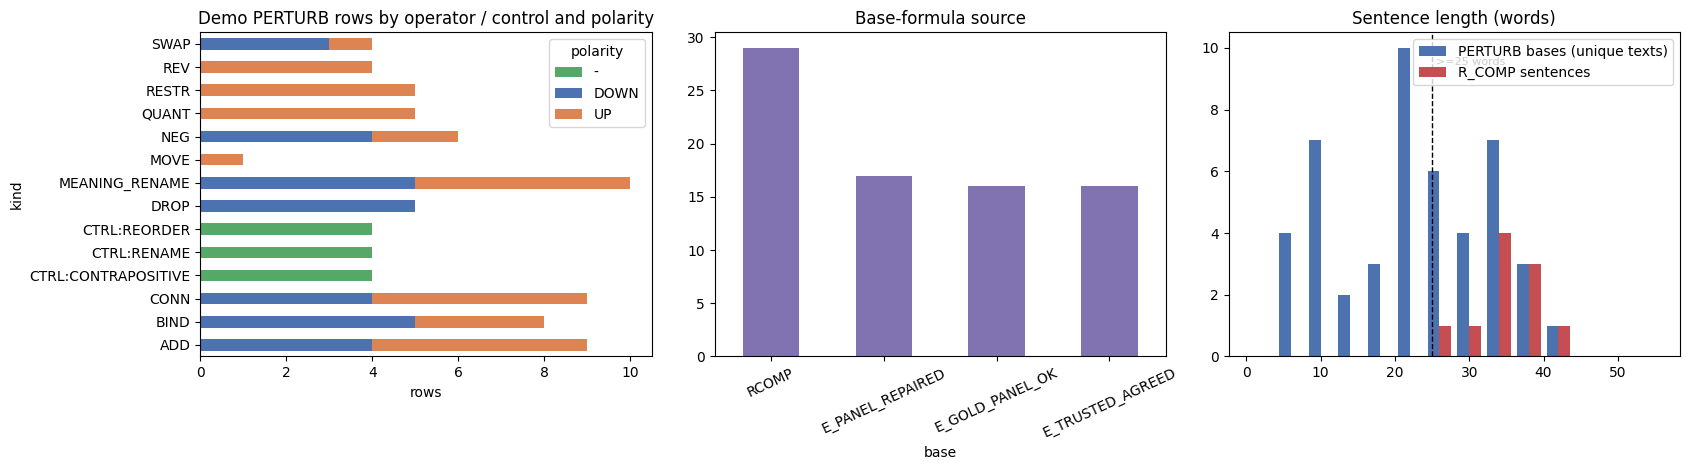

template                    clause  words  n_quant  depth  n_conditions
      T7                    unless     27        1      5             4
      T2               except_when     36        1      5             5
      T6 except_when+provided_that     42        1      5             5
      T9                    unless     36        1      5             5
      T8               but_only_if     34        1      6             5
      T7                    unless     28        1      4             4
      T8               but_only_if     35        1      5             5
      T5      provided_that+unless     36        1      6             5
      T1                    unless     34        1      5             5
      T3             provided_that     34        1      5             5


In [15]:
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

# 1) verification summary
ver = pd.DataFrame([{"group": g["dataset"], "rows": len(g["examples"]),
                     "verified": sum(e["metadata_source_verified"] for e in g["examples"])}
                    for g in groups + [{"dataset": "adjudicator_check", "examples": G["adjudicator_check"]}]])
ver["pass_rate"] = (ver["verified"] / ver["rows"]).round(3)
print("Source re-verification (original full run: 350/350, 5102/5102, 60/60 verified)")
print(ver.to_string(index=False), "\n")

# 2) PERTURB rows as a flat table
rows = []
for e in G["perturb_suite"]:
    inp = json.loads(e["input"])
    rows.append({"kind": e.get("metadata_operator") or "CTRL:" + e.get("metadata_control_type", "?"),
                 "subtype": e.get("metadata_subtype"), "polarity": e.get("metadata_position_polarity") or "-",
                 "base": e["metadata_base_source"], "label": e["output"], "words": e["metadata_strata"]["words"],
                 "text": inp["text"], "reference": inp["reference_fol"], "candidate": inp["candidate_fol"],
                 "verified": e["metadata_source_verified"]})
df = pd.DataFrame(rows)
print("One example per error type / control (short bases):")
ex = df.sort_values("words").groupby("kind").head(1).sort_values("kind")
for _, r in ex.iterrows():
    print(f"[{r.kind} / {r.subtype} / {r.polarity}] -> {r.label}\n  text: {r.text}\n  ref : {r.reference}\n  cand: {r.candidate}")
print()
print(pd.crosstab(df["kind"], df["base"], margins=True).to_string())

# 3) plots
rc_words = [e["metadata_strata"]["words"] for e in G["rcomp_sentences"]]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
ct = pd.crosstab(df["kind"], df["polarity"])
ct.plot(kind="barh", stacked=True, ax=axes[0], color=[{"DOWN": "#4C72B0", "UP": "#DD8452", "-": "#55A868"}[c] for c in ct.columns])
axes[0].set_title("Demo PERTURB rows by operator / control and polarity")
axes[0].set_xlabel("rows")
df["base"].value_counts().plot(kind="bar", ax=axes[1], color="#8172B2")
axes[1].set_title("Base-formula source")
axes[1].tick_params(axis="x", rotation=25)
axes[2].hist([df.drop_duplicates("text")["words"], rc_words], bins=range(0, 60, 4),
             label=["PERTURB bases (unique texts)", "R_COMP sentences"], color=["#4C72B0", "#C44E52"])
axes[2].axvline(25, ls="--", c="k", lw=1)
axes[2].text(25.5, axes[2].get_ylim()[1] * 0.9, ">=25 words", fontsize=8)
axes[2].set_title("Sentence length (words)")
axes[2].legend()
plt.tight_layout()
plt.show()

# 4) R_COMP complexity strata
print(pd.DataFrame([{"template": e["metadata_template_id"], "clause": e["metadata_clause_type"], **{k: e["metadata_strata"][k]
      for k in ("words", "n_quant", "depth", "n_conditions")}} for e in G["rcomp_sentences"]]).to_string(index=False))